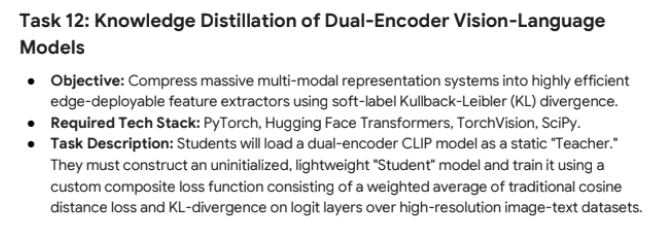

In [ ]:
!pip install transformers torch torchvision matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

from transformers import (
    CLIPProcessor,
    CLIPModel
)

The following code defines the transformations to apply to the images, loads the CIFAR10 dataset, and prints the classes available in the dataset. This ensures the `dataset` variable is correctly initialized for subsequent steps.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(
    "Dataset loaded!"
)

print(
    "Classes:",
    classes
)

100%|██████████| 170M/170M [22:19<00:00, 127kB/s]


Dataset loaded!
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [ ]:
teacher_name = (
    "openai/clip-vit-base-patch32"
)

teacher = CLIPModel.from_pretrained(
    teacher_name
).to(device)

processor = CLIPProcessor.from_pretrained(
    teacher_name
)

teacher.eval()

print(
    "CLIP Teacher loaded successfully!"
)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP Teacher loaded successfully!


In [ ]:
class StudentVisionModel(
    nn.Module
):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.projection = nn.Linear(
            128,
            512
        )


    def forward(self, x):

        x = self.network(x)

        x = x.flatten(
            start_dim=1
        )

        x = self.projection(x)

        x = F.normalize(
            x,
            dim=1
        )

        return x

In [ ]:
student = StudentVisionModel().to(
    device
)

print(student)

StudentVisionModel(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (projection): Linear(in_features=128, out_features=512, bias=True)
)


In [ ]:
images = []

labels = []

for i in range(16):

    image, label = dataset[i]

    images.append(image)

    labels.append(label)

texts = [
    f"a photo of a {classes[label]}"
    for label in labels
]

print(
    "Number of image-text pairs:",
    len(images)
)

Number of image-text pairs: 16


In [ ]:
image_batch = torch.stack(
    images
).to(device)

text_inputs = processor(
    text=texts,
    return_tensors="pt",
    padding=True
)

text_inputs = {
    key: value.to(device)
    for key, value in text_inputs.items()
}


with torch.no_grad():

    teacher_image_embeddings = (
        teacher.get_image_features(
            pixel_values=image_batch
        ).pooler_output # Extract the tensor from BaseModelOutputWithPooling
    )

    teacher_text_embeddings = (
        teacher.get_text_features(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"]
        ).pooler_output # Extract the tensor from BaseModelOutputWithPooling
    )


teacher_image_embeddings = F.normalize(
    teacher_image_embeddings,
    dim=1
)

teacher_text_embeddings = F.normalize(
    teacher_text_embeddings,
    dim=1
)


print(
    "Teacher embeddings generated!"
)

print(
    "Image embedding shape:",
    teacher_image_embeddings.shape
)

Teacher embeddings generated!
Image embedding shape: torch.Size([16, 512])


In [ ]:
optimizer = torch.optim.Adam(
    student.parameters(),
    lr=1e-3
)

loss_history = []

epochs = 10

for epoch in range(epochs):

    student.train()

    student_embeddings = student(
        image_batch
    )

    # --------------------------------------------------------
    # 1. Feature distillation loss
    # --------------------------------------------------------

    feature_loss = F.mse_loss(
        student_embeddings,
        teacher_image_embeddings
    )


    # --------------------------------------------------------
    # 2. Contrastive similarity
    # --------------------------------------------------------

    student_similarity = (
        student_embeddings
        @ teacher_text_embeddings.T
    )

    teacher_similarity = (
        teacher_image_embeddings
        @ teacher_text_embeddings.T
    )


    # --------------------------------------------------------
    # 3. KL divergence
    # --------------------------------------------------------

    temperature = 0.07

    student_prob = F.log_softmax(
        student_similarity / temperature,
        dim=1
    )

    teacher_prob = F.softmax(
        teacher_similarity / temperature,
        dim=1
    )

    kl_loss = F.kl_div(
        student_prob,
        teacher_prob,
        reduction="batchmean"
    )


    # --------------------------------------------------------
    # 4. Combined loss
    # --------------------------------------------------------

    loss = (
        feature_loss
        +
        kl_loss
    )


    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    loss_history.append(
        loss.item()
    )


    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"Loss: {loss.item():.4f}"
    )

Epoch 1/10 Loss: 0.0670
Epoch 2/10 Loss: 0.0431
Epoch 3/10 Loss: 0.0427
Epoch 4/10 Loss: 0.0406
Epoch 5/10 Loss: 0.0399
Epoch 6/10 Loss: 0.0392
Epoch 7/10 Loss: 0.0381
Epoch 8/10 Loss: 0.0364
Epoch 9/10 Loss: 0.0348
Epoch 10/10 Loss: 0.0333


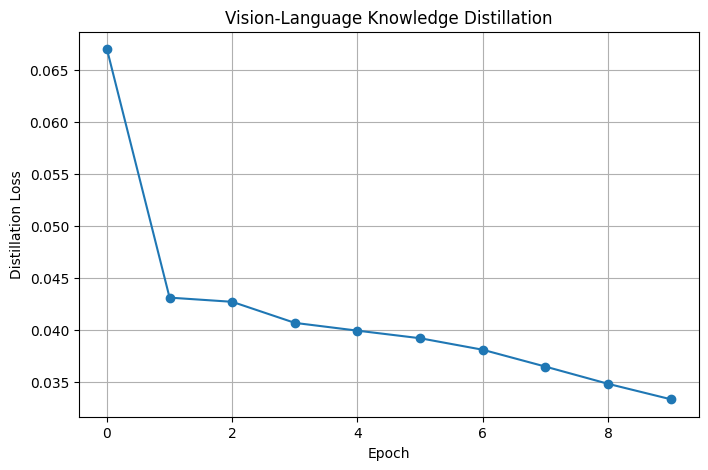

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Distillation Loss"
)

plt.title(
    "Vision-Language Knowledge Distillation"
)

plt.grid()

plt.show()

In [ ]:
student.eval()

with torch.no_grad():

    student_embeddings = student(
        image_batch
    )

similarities = (
    torch.sum(
        student_embeddings
        *
        teacher_image_embeddings,
        dim=1
    )
)

similarities = (
    similarities
    .cpu()
    .numpy()
)

print(
    "Teacher-Student Cosine Similarities:"
)

for i, similarity in enumerate(
    similarities
):

    print(
        f"Image {i+1}: "
        f"{similarity:.4f}"
    )

Teacher-Student Cosine Similarities:
Image 1: -0.0975
Image 2: -0.0722
Image 3: -0.0942
Image 4: -0.0532
Image 5: -0.0301
Image 6: -0.0534
Image 7: -0.0304
Image 8: -0.0339
Image 9: -0.0583
Image 10: -0.0584
Image 11: -0.0495
Image 12: -0.0949
Image 13: -0.0453
Image 14: -0.0672
Image 15: -0.0877
Image 16: -0.0575


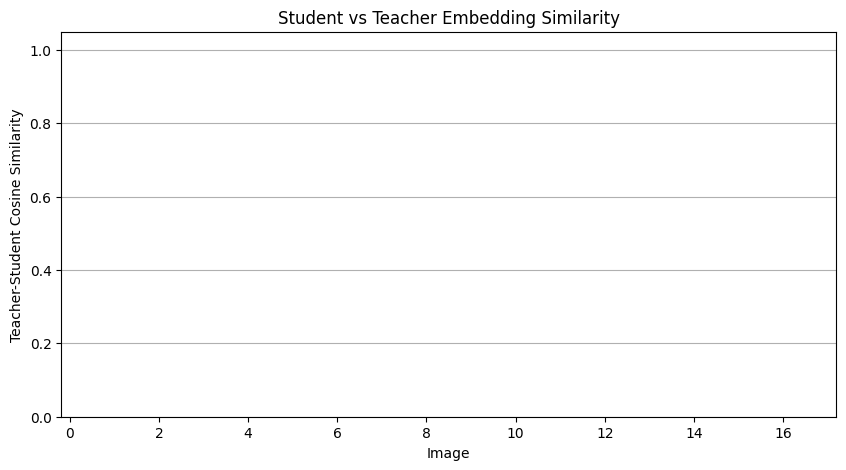

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    range(1, len(similarities) + 1),
    similarities
)

plt.xlabel(
    "Image"
)

plt.ylabel(
    "Teacher-Student Cosine Similarity"
)

plt.title(
    "Student vs Teacher Embedding Similarity"
)

plt.ylim(
    0,
    1.05
)

plt.grid(
    axis="y"
)

plt.show()